# Практична робота №16
## Кореляційний аналіз: Пірсон, Спірмен, кореляційна матриця
**Виконав:** Хрустовський Павло  
**Група:** ІТ-42  
**Варіант:** 6 (Чернігів)  
**№ у журналі:** 26


Характер зв'язку: виражений спадний лінійний тренд — зі зростанням температури витрати знижуються.


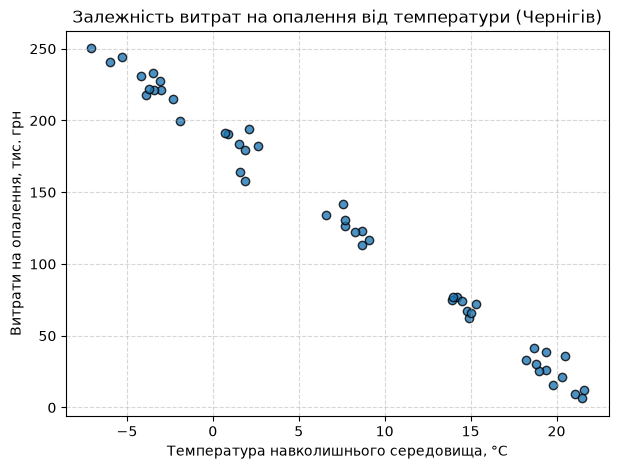

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(6)
city = "Чернігів"
base_t = 8.0
amp_t = 13.0

rows = []
for yr in range(2021, 2025):
    for m in range(1, 13):
        t = base_t + amp_t * np.cos((m - 7) / 12 * 2 * np.pi) + np.random.normal(0, 1.0)
        h_days = max(0, int(round(25 - 1.2 * t + np.random.normal(0, 1.5))))
        h_cost = round(150 - 6.5 * t + 1.8 * h_days + np.random.normal(0, 8.0), 1)
        rows.append({
            "температура": round(t, 1),
            "опалювальні_дні": h_days,
            "витрати_на_опалення": h_cost
        })

climate = pd.DataFrame(rows)

plt.figure(figsize=(7, 5))
plt.scatter(climate["температура"], climate["витрати_на_опалення"], color="#1f77b4", edgecolors="black", alpha=0.8)
plt.xlabel("Температура навколишнього середовища, °C")
plt.ylabel("Витрати на опалення, тис. грн")
plt.title(f"Залежність витрат на опалення від температури ({city})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("Характер зв'язку: виражений спадний лінійний тренд — зі зростанням температури витрати знижуються.")


In [2]:
from scipy.stats import pearsonr, spearmanr, norm

r_pearson, p_pearson = pearsonr(climate["температура"], climate["витрати_на_опалення"])
rho_spearman, p_spearman = spearmanr(climate["температура"], climate["витрати_на_опалення"])

print(f"Коефіцієнт Пірсона: r = {r_pearson:.3f}, p-value = {p_pearson:.3e}")
print(f"Коефіцієнт Спірмена: rho = {rho_spearman:.3f}, p-value = {p_spearman:.3e}")

# 95% довірчий інтервал через z-перетворення Фішера
n = len(climate)
z_val = np.arctanh(r_pearson)
se_z = 1 / np.sqrt(n - 3)
crit = norm.ppf(0.975)
ci_lower = np.tanh(z_val - crit * se_z)
ci_upper = np.tanh(z_val + crit * se_z)
print(f"95% довірчий інтервал для коефіцієнта Пірсона: ({ci_lower:.3f}, {ci_upper:.3f})")


Коефіцієнт Пірсона: r = -0.996, p-value = 3.476e-49
Коефіцієнт Спірмена: rho = -0.988, p-value = 9.491e-39
95% довірчий інтервал для коефіцієнта Пірсона: (-0.998, -0.992)


In [3]:
corr_cols = climate[["температура", "опалювальні_дні", "витрати_на_опалення"]]

print("Кореляційна матриця (Пірсон):")
print(corr_cols.corr().round(3))

print("\nКореляційна матриця (Спірмен):")
print(corr_cols.corr(method="spearman").round(3))


Кореляційна матриця (Пірсон):
                     температура  опалювальні_дні  витрати_на_опалення
температура                1.000           -0.986               -0.996
опалювальні_дні           -0.986            1.000                0.987
витрати_на_опалення       -0.996            0.987                1.000

Кореляційна матриця (Спірмен):
                     температура  опалювальні_дні  витрати_на_опалення
температура                1.000           -0.980               -0.988
опалювальні_дні           -0.980            1.000                0.987
витрати_на_опалення       -0.988            0.987                1.000


### Причинно-наслідковий характер виявленого зв'язку
Виявлена тісна кореляція між температурою та витратами на опалення зумовлена безпосереднім фізичним процесом тепловтрат будівель (закон теплопровідності Фур'є). Це прямий причинний зв'язок, на відміну від псевдокореляцій, породжених прихованими факторами (confounders).


In [4]:
outlier_entry = pd.DataFrame([{
    "температура": -2.0,
    "опалювальні_дні": 25,
    "витрати_на_опалення": 20.0  # аномально низькі витрати через збій обліку
}])

climate_anom = pd.concat([climate, outlier_entry], ignore_index=True)

r_anom, p_r_anom = pearsonr(climate_anom["температура"], climate_anom["витрати_на_опалення"])
rho_anom, p_rho_anom = spearmanr(climate_anom["температура"], climate_anom["витрати_на_опалення"])

print(f"Пірсон із викидом:  r = {r_anom:.3f} (було {r_pearson:.3f})")
print(f"Спірмен із викидом: rho = {rho_anom:.3f} (було {rho_spearman:.3f})")


Пірсон із викидом:  r = -0.938 (було -0.996)
Спірмен із викидом: rho = -0.931 (було -0.988)


### Відповіді на контрольні запитання

1. **Чому коефіцієнт кореляції Пірсона ділиться на добуток стандартних відхилень і завжди знаходиться в діапазоні [-1; 1]?**  
   Ділення коваріації на добуток стандартних відхилень $\sigma_x \sigma_y$ нормалізує величину, роблячи її безрозмірною та інваріантною до вибору одиниць вимірювання. Межі $[-1; 1]$ строго випливають із нерівності Коші-Буняковського для скалярного добутку центрованих векторів у евклідовому просторі.

2. **Чому коефіцієнт Спірмена розраховується на рангах і чому він стійкий до викидів?**  
   Заміна числових значень їх порядковими рангами усуває вплив надмірної амплітуди аномальних точок (викидів): навіть якщо значення відхилилося в сотні разів, його ранг зміниться лише на кілька позицій. Це робить рангову кореляцію Спірмена непараметричною та робастною.
